In [1]:
COLAB = "google.colab" in str(get_ipython())

In [ ]:
if COLAB:
    ! git clone --branch main https://github.com/ST4-BlackSwan/Higgs-TeamB.git

    %cd Higgs-TeamB/BDT

    ! git status

Cloning into 'Higgs-TeamB'...
remote: Enumerating objects: 827, done.
remote: Counting objects: 100% (287/287), done.
remote: Compressing objects: 100% (176/176), done.
remote: Total 827 (delta 176), reused 150 (delta 111), pack-reused 540 (from 2)
Receiving objects: 100% (827/827), 13.05 MiB | 19.07 MiB/s, done.
Resolving deltas: 100% (450/450), done.
/content/Higgs-TeamB/BDT
On branch BDT_collab
Your branch is up to date with 'origin/BDT_collab'.

nothing to commit, working tree clean


In [ ]:
!pip install HiggsML
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 16.8 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 21.6 MB/s eta 0:00:00


In [ ]:
import os
import sys
root_dir = os.getcwd()
print("Root directory is", root_dir)

submission_dir = os.path.join(os.path.dirname(root_dir), "BDT")

# The directory where results and other outputs from the participant's code will be written
output_dir = os.path.join(root_dir, "sample_result_submission")

sys.path.append(submission_dir)


Root directory is /content/Higgs-TeamB/BDT


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from HiggsML.datasets import download_dataset
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import optuna
from boosted_decision_tree_opt import BoostedDecisionTree

# Load Data
First we load data from the HiggsML library and we split it into training (70%) and testing (30%) data.

In [ ]:
data = download_dataset(
    "blackSwan_data")
data.load_train_set()
data_set = data.get_train_set()

train_data = data_set.drop(columns=["labels", "weights", "detailed_labels"])
labels = data_set["labels"]
weights = data_set["weights"]

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    train_data,
    labels,
    weights,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

# Train model
Here we instanciate a bdt with our best hyperparameter configuration. Then we use the fit function from xgboost library passing the train data in parameter to train our boosted decision tree.

In [ ]:
bdt = BoostedDecisionTree(
    max_depth=9,
    learning_rate=0.015619081519761545,
    subsample=0.8,
    colsample_bytree=1.0,
    min_child_weight=4
)

bdt.fit(X_train, y_train, w_train) # [6 min]

[INFO] scale_pos_weight configuré à 155.41
AUC = 0.883891464458067


# Test model
Here we show different plots to showcase the efficiency of our BDT model :

* AUC

We obtain an AUC of 0.884, which is acceptable

In [ ]:

predictions = bdt.predict(X_test) # [30s]

auc = roc_auc_score(y_test, predictions, sample_weight=w_test)

print("AUC =", auc)

AUC = 0.883891464458067


* ROC curve

Here we plot the true positive rate as a function of the fasle positive rate (ROC curve)

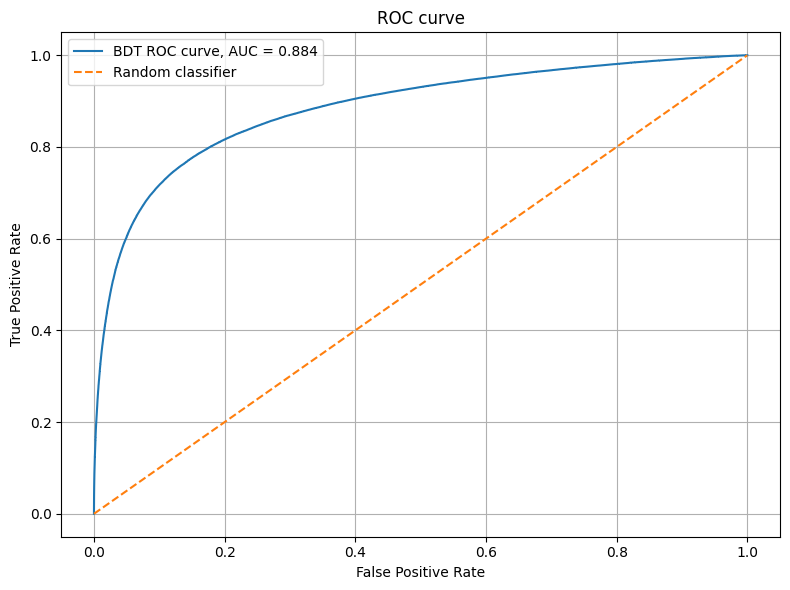

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    predictions,
    sample_weight=w_test
)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"BDT ROC curve, AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

* significance curve

Here we plot the Poisson significance $Z = \sqrt{2 \left( (S + B) \ln\left(1 + \frac{S}{B}\right) - S \right)} \sim \frac{S}{\sqrt B}$ as a function of BDT threshold.

Best threshold: 0.9597989949748744
Best Poisson significance: 3.3231441295192767


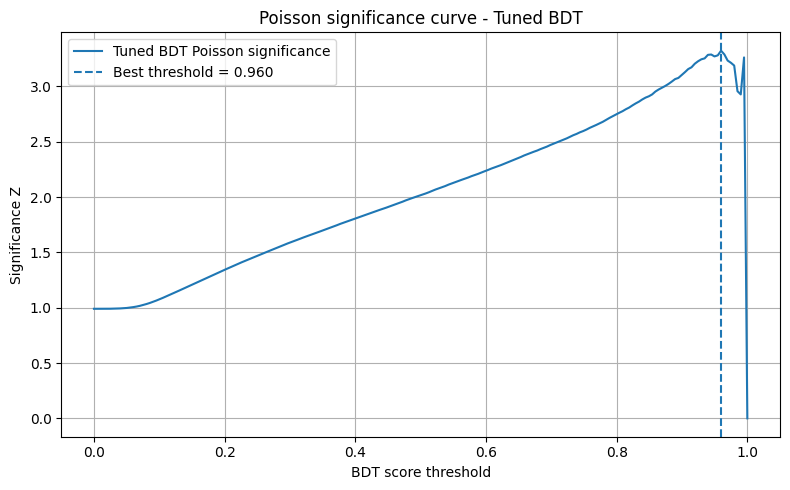

In [ ]:
thresholds = np.linspace(0, 1, 200)

significances = []
S_values = []
B_values = []

w_test_s_norm = w_test[labels == 1] / np.sum(w_test[labels == 1]) * 1015
w_test_b_norm = w_test[labels == 0] / np.sum(w_test[labels == 0]) * 1050370

for threshold in thresholds:
    selected = predictions > threshold

    S = np.sum(w_test_s_norm[(y_test == 1) & selected])
    B = np.sum(w_test_b_norm[(y_test == 0) & selected])

    if S > 0 and B > 0:
        Z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))
    else:
        Z = 0

    significances.append(Z)
    S_values.append(S)
    B_values.append(B)

significances = np.array(significances)

best_index = np.argmax(significances)
best_threshold = thresholds[best_index]
best_significance = significances[best_index]

print("Best threshold:", best_threshold)
print("Best Poisson significance:", best_significance)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, significances, label="Tuned BDT Poisson significance")
plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.3f}"
)

plt.xlabel("BDT score threshold")
plt.ylabel("Significance Z")
plt.title("Poisson significance curve - Tuned BDT")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

* signal vs background normalized score distribution

Here we plot the normalized weighted density for each score, for both signal (blue) and noise (orange)

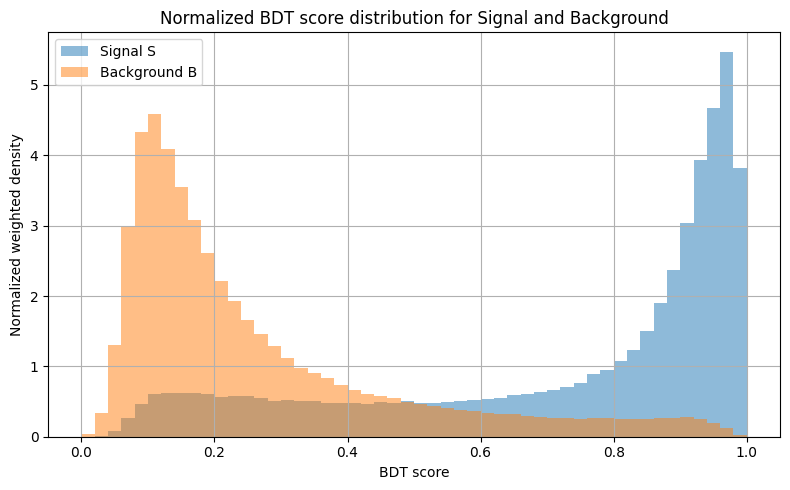

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    predictions[y_test == 1],
    bins=50,
    range=(0, 1),
    weights=w_test[y_test == 1],
    density=True,
    alpha=0.5,
    label="Signal S"
)

plt.hist(
    predictions[y_test == 0],
    bins=50,
    range=(0, 1),
    weights=w_test[y_test == 0],
    density=True,
    alpha=0.5,
    label="Background B"
)

plt.xlabel("BDT score")
plt.ylabel("Normalized weighted density")
plt.title("Normalized BDT score distribution for Signal and Background")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()